Imports et connexion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import f_oneway, chi2_contingency, kruskal
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"]      = 12

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@localhost:5432/"
    f"{os.getenv('POSTGRES_DB')}"
)

df_deputes  = pd.read_sql(
    "SELECT * FROM deputes WHERE groupe_sigle IS NOT NULL", engine
)
df_groupes  = pd.read_sql(
    "SELECT * FROM groupes_politiques", engine
)
df_scrutins = pd.read_sql("SELECT * FROM scrutins", engine)
df_scrutins["adopte"] = df_scrutins["adopte"].apply(
    lambda x: True if x is True or x == 1
    or str(x).lower() == "true" else False
)

def nettoyer_valeur(val):
    if isinstance(val, dict):
        if "@xsi:nil" in val or "@xmlns:xsi" in val:
            return None
        for k in ("#text", "value", "text"):
            if k in val:
                return str(val[k])
        return None
    if isinstance(val, str) and val.startswith("{'@"):
        return None
    return val

df_deputes["profession"]     = df_deputes["profession"].apply(nettoyer_valeur)
df_deputes["date_naissance"] = pd.to_datetime(
    df_deputes["date_naissance"], errors="coerce"
)
df_deputes["genre"] = df_deputes["civilite"].map(
    {"M.": "Homme", "Mme": "Femme"}
)

COULEURS_GROUPES = {
    "RN":      "#1E3A8A", "EPR":     "#DAA520",
    "LFI-NFP": "#CC0000", "SOC":     "#E91E63",
    "DR":      "#1565C0", "ECO":     "#2E7D32",
    "DEM":     "#FF8F00", "HOR":     "#00838F",
    "LIOT":    "#6A1B9A", "GDR":     "#B71C1C",
    "UDR":     "#0D47A1", "NI":      "#757575",
}

print(f"✅ {len(df_deputes):,} députés | "
      f"{len(df_scrutins):,} scrutins | "
      f"{len(df_groupes)} groupes")

✅ 577 députés | 6,899 scrutins | 12 groupes


Blocs politiques et statistiques

In [2]:
blocs = {
    "Gauche":  ["LFI-NFP", "SOC", "ECO", "GDR"],
    "Centre":  ["EPR", "DEM", "HOR", "LIOT"],
    "Droite":  ["RN", "DR", "UDR", "NI"],
}
couleurs_blocs = {
    "Gauche": "#CC0000",
    "Centre": "#DAA520",
    "Droite": "#1E3A8A",
}

df_deputes["bloc"] = df_deputes["groupe_sigle"].apply(
    lambda g: next(
        (b for b, groupes in blocs.items() if g in groupes), "Autre"
    )
)

print("── STATISTIQUES PAR BLOC POLITIQUE ────────────────")
print(f"\n{'Métrique':<25} {'Gauche':>10} {'Centre':>10} {'Droite':>10}")
print("-" * 58)

ages_blocs = {}
for bloc in ["Gauche", "Centre", "Droite"]:
    df_bloc = df_deputes[df_deputes["bloc"] == bloc]
    ages_blocs[bloc] = df_bloc["age"].dropna().values
    nb       = len(df_bloc)
    age_moy  = df_bloc["age"].mean()
    age_std  = df_bloc["age"].std()
    age_med  = df_bloc["age"].median()
    pct_f    = (df_bloc["genre"] == "Femme").mean() * 100
    print(f"{'Effectif':<25} {nb:>10}")
    print(f"{'Âge moyen':<25} {age_moy:>10.1f}")
    print(f"{'Âge std':<25} {age_std:>10.1f}")
    print(f"{'Âge médian':<25} {age_med:>10.1f}")
    print(f"{'% Femmes':<25} {pct_f:>9.1f}%")
    print()

# Test Kruskal-Wallis (non paramétrique) sur les âges par bloc
h_stat, p_kruskal = kruskal(*ages_blocs.values())
print(f"── TEST KRUSKAL-WALLIS (âge par bloc) ─────────────")
print(f"   H={h_stat:.3f} | p={p_kruskal:.4f}")
print(f"   → {'Différences significatives ✓' if p_kruskal < 0.05 else 'Pas de différence significative'}")

# Test Chi2 parité par bloc
contingency_blocs = pd.crosstab(df_deputes["bloc"], df_deputes["genre"])
chi2_blocs, p_chi2_blocs, dof_blocs, _ = chi2_contingency(contingency_blocs)
print(f"\n── TEST CHI2 (parité par bloc) ─────────────────────")
print(f"   χ²={chi2_blocs:.3f} | p={p_chi2_blocs:.4f} | ddl={dof_blocs}")
print(f"   → {'Différences significatives ✓' if p_chi2_blocs < 0.05 else 'Pas de différence significative'}")

── STATISTIQUES PAR BLOC POLITIQUE ────────────────

Métrique                      Gauche     Centre     Droite
----------------------------------------------------------
Effectif                         194
Âge moyen                       49.6
Âge std                         11.2
Âge médian                      50.0
% Femmes                       41.2%

Effectif                         186
Âge moyen                       54.7
Âge std                         10.7
Âge médian                      56.0
% Femmes                       40.9%

Effectif                         197
Âge moyen                       50.2
Âge std                         13.3
Âge médian                      52.0
% Femmes                       32.0%

── TEST KRUSKAL-WALLIS (âge par bloc) ─────────────
   H=19.369 | p=0.0001
   → Différences significatives ✓

── TEST CHI2 (parité par bloc) ─────────────────────
   χ²=4.541 | p=0.1033 | ddl=2
   → Pas de différence significative


Professions par bloc politique

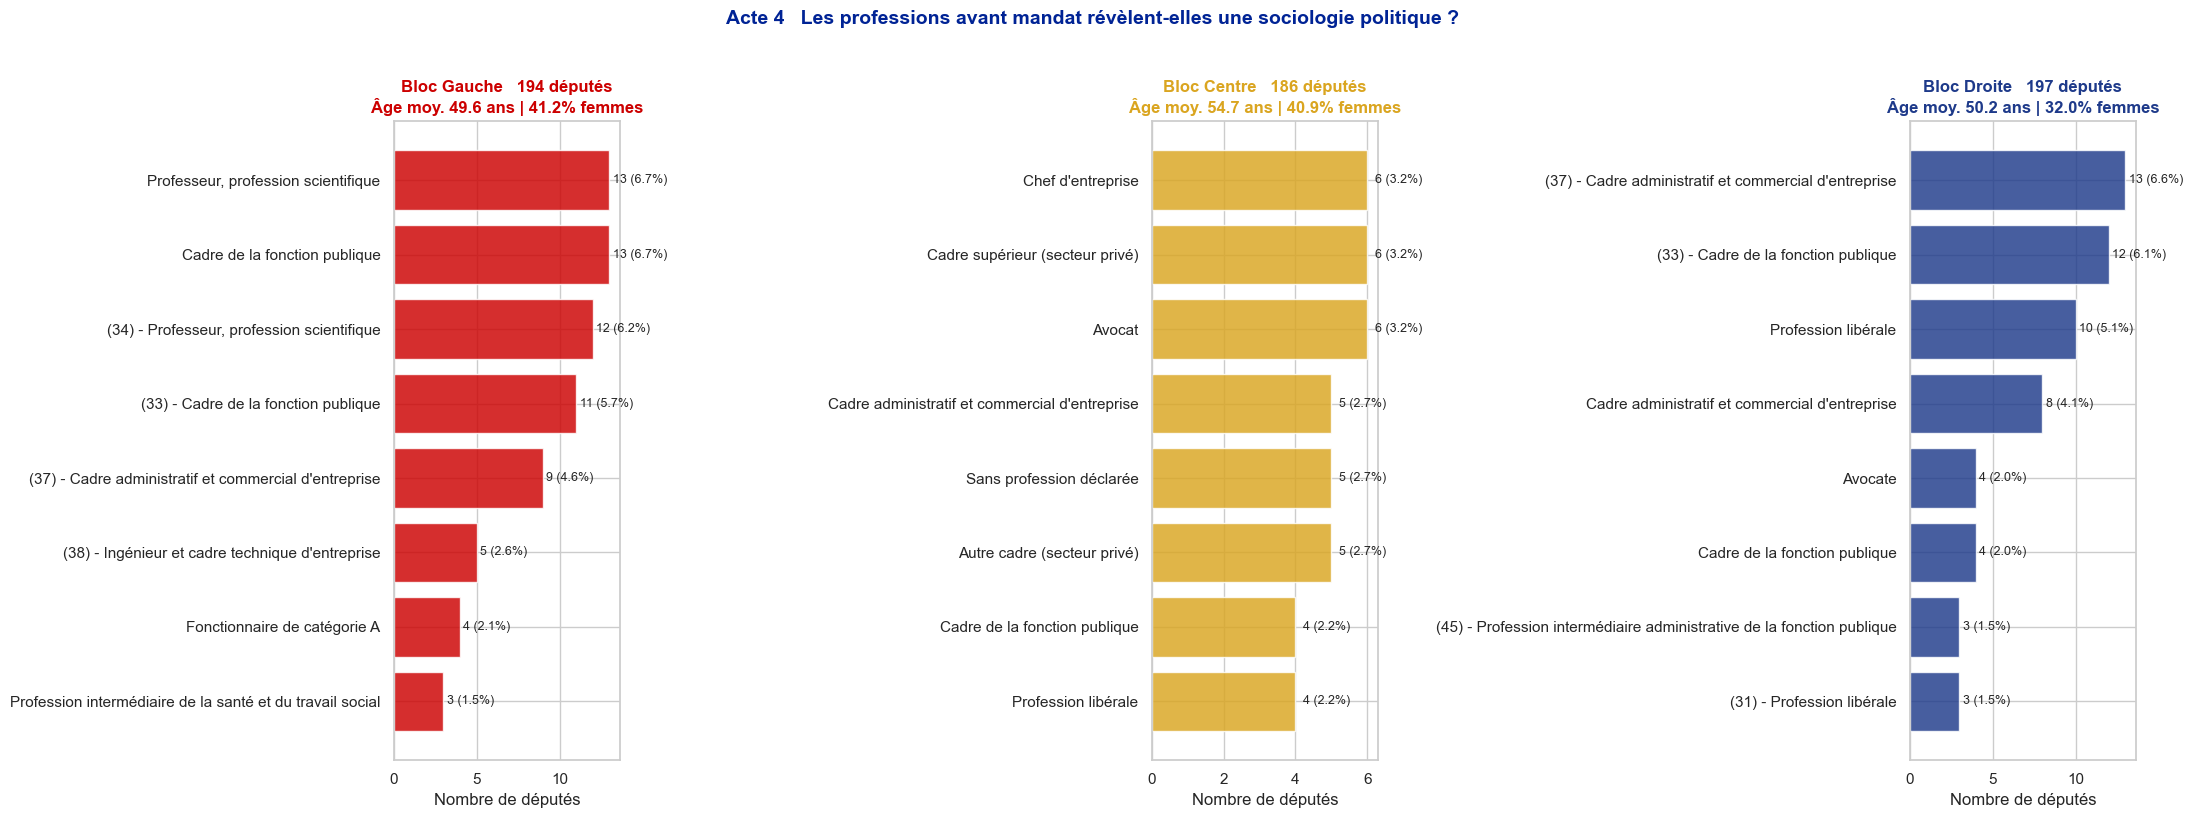

✅ Figure 10 sauvegardée


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for i, (bloc, color) in enumerate(couleurs_blocs.items()):
    df_bloc  = df_deputes[df_deputes["bloc"] == bloc]
    top_prof = (
        df_bloc["profession"].dropna()
        .value_counts().head(8)
        .reset_index()
    )
    top_prof.columns = ["profession", "nb"]
    top_prof["pct"]  = (
        top_prof["nb"] / df_bloc["profession"].notna().sum() * 100
    ).round(1)

    axes[i].barh(
        top_prof["profession"], top_prof["nb"],
        color=color, edgecolor="white", alpha=0.82
    )
    for j, (nb, pct) in enumerate(zip(top_prof["nb"], top_prof["pct"])):
        axes[i].text(nb + 0.2, j, f"{nb} ({pct}%)",
                     va="center", fontsize=9)
    axes[i].invert_yaxis()
    axes[i].set_title(
        f"Bloc {bloc}   {len(df_bloc)} députés\n"
        f"Âge moy. {df_bloc['age'].mean():.1f} ans | "
        f"{(df_bloc['genre']=='Femme').mean()*100:.1f}% femmes",
        fontsize=12, fontweight="bold", color=color
    )
    axes[i].set_xlabel("Nombre de députés")

plt.suptitle(
    "Acte 4   Les professions avant mandat révèlent-elles "
    "une sociologie politique ?",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/10_professions_par_bloc.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 10 sauvegardée")

Âge et genre par groupe

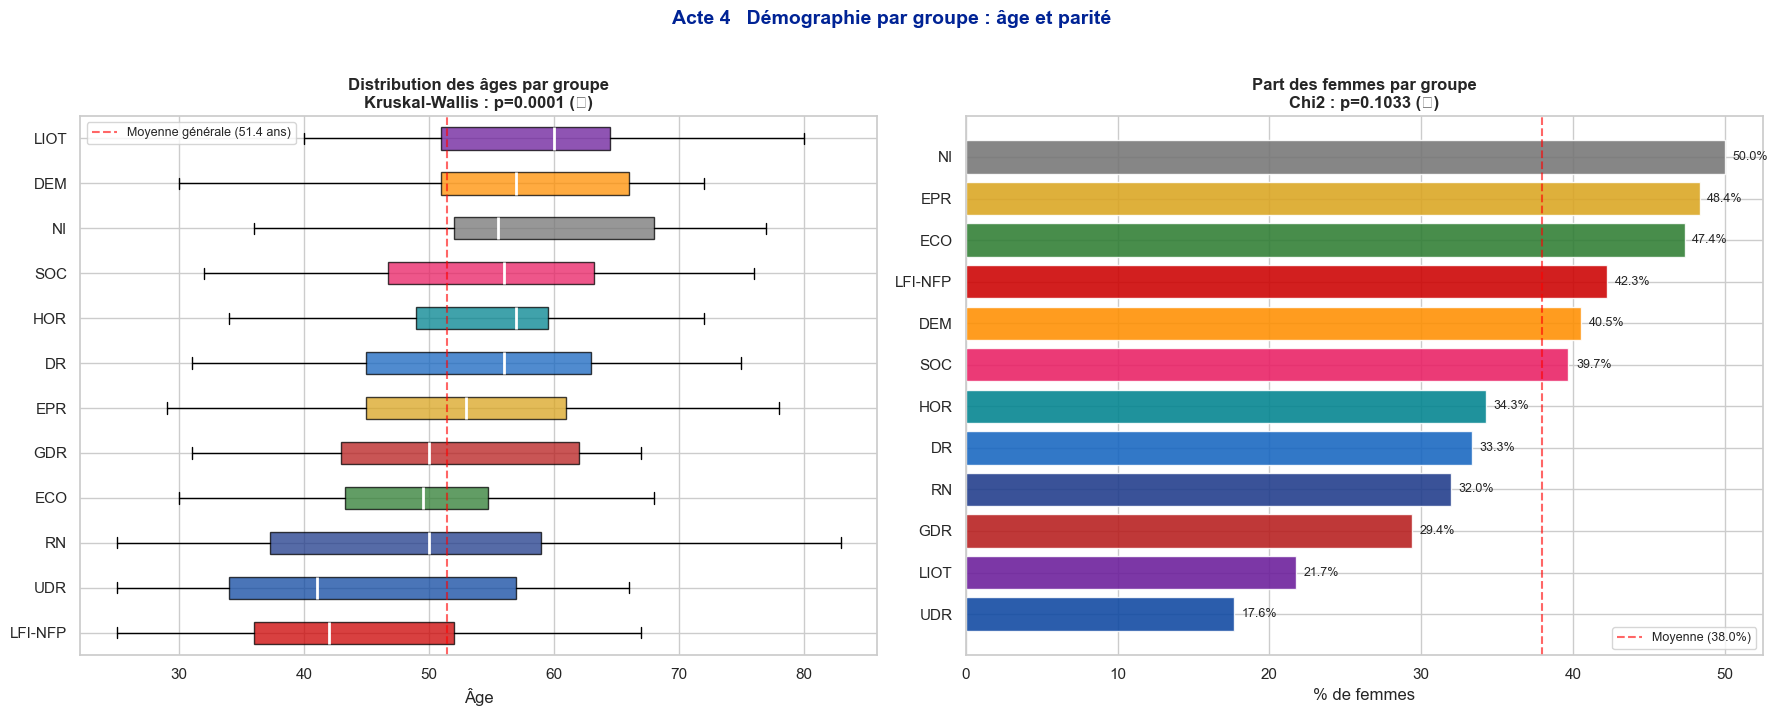

✅ Figure 11 sauvegardée


In [4]:
age_par_groupe = (
    df_deputes.groupby("groupe_sigle")["age"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
    .sort_values("mean")
)
femmes_par_groupe = (
    df_deputes.groupby("groupe_sigle")
    .apply(lambda x: (x["genre"] == "Femme").mean() * 100)
    .reset_index(name="pct_femmes")
)
stats_groupe = age_par_groupe.merge(femmes_par_groupe, on="groupe_sigle")
stats_groupe["couleur"] = stats_groupe["groupe_sigle"].map(COULEURS_GROUPES)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Boxplot âge par groupe
bp_data = [
    df_deputes[df_deputes["groupe_sigle"] == g]["age"].dropna().values
    for g in stats_groupe["groupe_sigle"]
]
bp = axes[0].boxplot(
    bp_data,
    patch_artist=True,
    vert=False,
    medianprops=dict(color="white", linewidth=2)
)
for patch, color in zip(bp["boxes"], stats_groupe["couleur"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_yticklabels(stats_groupe["groupe_sigle"])
axes[0].axvline(
    df_deputes["age"].mean(), color="red",
    linestyle="--", alpha=0.6,
    label=f"Moyenne générale ({df_deputes['age'].mean():.1f} ans)"
)
axes[0].set_xlabel("Âge")
axes[0].set_title(
    "Distribution des âges par groupe\n"
    f"Kruskal-Wallis : p={p_kruskal:.4f} "
    f"({'✓' if p_kruskal < 0.05 else '✗'})",
    fontsize=12, fontweight="bold"
)
axes[0].legend(fontsize=9)

# % Femmes par groupe
femmes_sort = stats_groupe.sort_values("pct_femmes")
bars = axes[1].barh(
    femmes_sort["groupe_sigle"],
    femmes_sort["pct_femmes"],
    color=femmes_sort["couleur"],
    edgecolor="white", alpha=0.88
)
axes[1].axvline(
    (df_deputes["genre"] == "Femme").mean() * 100,
    color="red", linestyle="--", alpha=0.6,
    label=f"Moyenne ({(df_deputes['genre']=='Femme').mean()*100:.1f}%)"
)
for bar, val in zip(bars, femmes_sort["pct_femmes"]):
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{val:.1f}%", va="center", fontsize=9
    )
axes[1].set_xlabel("% de femmes")
axes[1].set_title(
    "Part des femmes par groupe\n"
    f"Chi2 : p={p_chi2_blocs:.4f} "
    f"({'✓' if p_chi2_blocs < 0.05 else '✗'})",
    fontsize=12, fontweight="bold"
)
axes[1].legend(fontsize=9)

plt.suptitle(
    "Acte 4   Démographie par groupe : âge et parité",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/11_age_genre_par_groupe.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 11 sauvegardée")

Villes de naissance

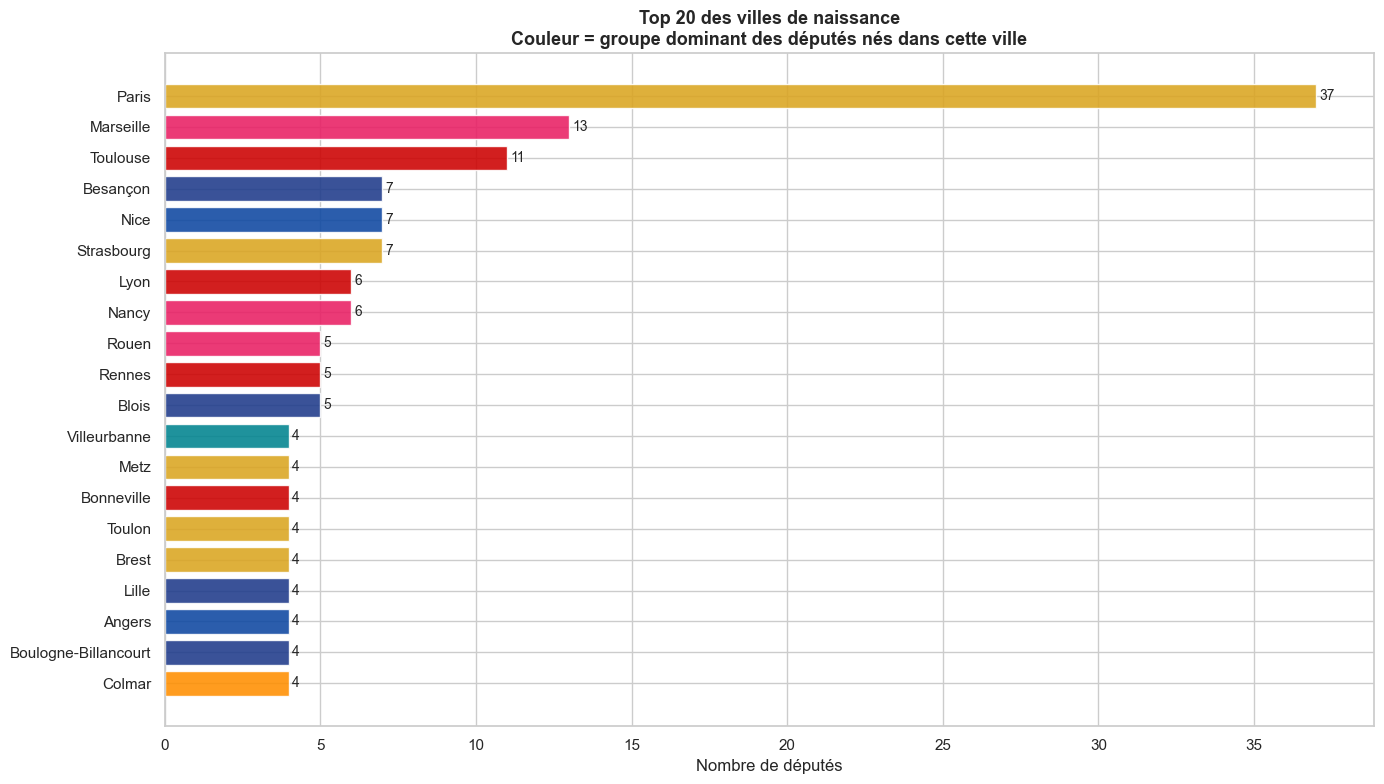

✅ Figure 12 sauvegardée


In [5]:
top_villes = (
    df_deputes["lieu_naissance"]
    .dropna()
    .value_counts()
    .head(20)
    .reset_index()
)
top_villes.columns = ["ville", "nb"]

def couleur_ville(ville):
    deputes_ville = df_deputes[df_deputes["lieu_naissance"] == ville]
    if deputes_ville.empty:
        return "#757575"
    groupe_dominant = deputes_ville["groupe_sigle"].value_counts().index[0]
    return COULEURS_GROUPES.get(groupe_dominant, "#757575")

top_villes["couleur"] = top_villes["ville"].apply(couleur_ville)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(
    top_villes["ville"], top_villes["nb"],
    color=top_villes["couleur"],
    edgecolor="white", alpha=0.88
)
for bar, val in zip(bars, top_villes["nb"]):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        str(val), va="center", fontsize=10
    )
ax.invert_yaxis()
ax.set_xlabel("Nombre de députés")
ax.set_title(
    "Top 20 des villes de naissance\n"
    "Couleur = groupe dominant des députés nés dans cette ville",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../data/processed/12_villes_naissance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 12 sauvegardée")

Scrutins par année et résultat

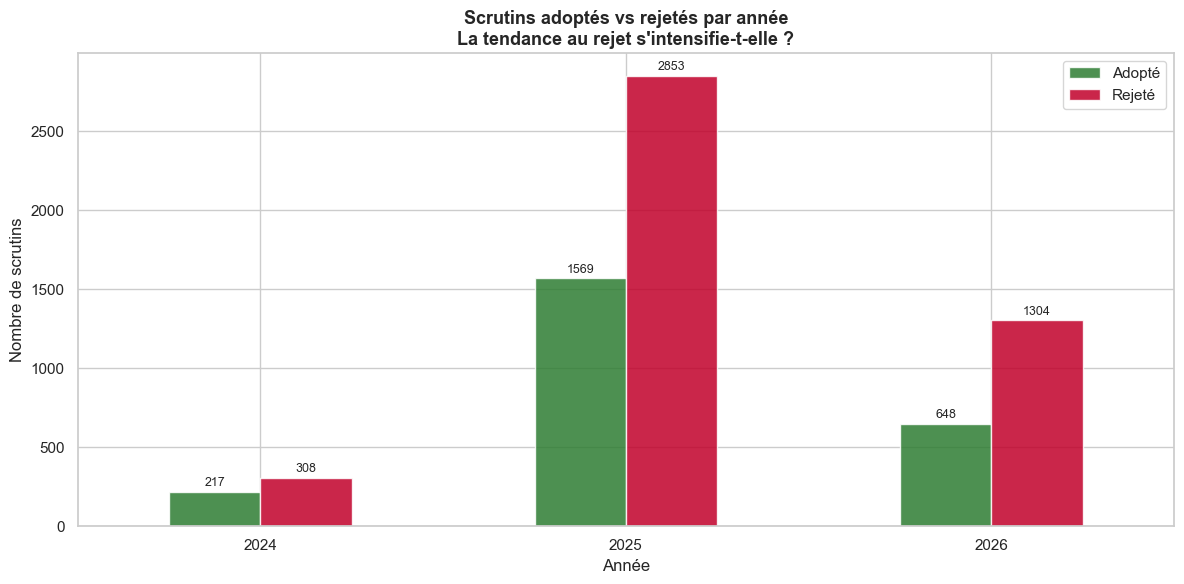

✅ Figure 13 sauvegardée


In [6]:
scrutins_annee = (
    df_scrutins
    .groupby(["annee", "sort"])
    .size()
    .reset_index(name="nb")
    .pivot(index="annee", columns="sort", values="nb")
    .fillna(0)
)

ax = scrutins_annee.plot(
    kind="bar", figsize=(12, 6),
    color={"adopté": "#2E7D32", "rejeté": "#C1002A"},
    edgecolor="white", alpha=0.85
)
plt.title(
    "Scrutins adoptés vs rejetés par année\n"
    "La tendance au rejet s'intensifie-t-elle ?",
    fontsize=13, fontweight="bold"
)
plt.xlabel("Année")
plt.ylabel("Nombre de scrutins")
plt.xticks(rotation=0)
plt.legend(["Adopté", "Rejeté"])

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=2)

plt.tight_layout()
plt.savefig("../data/processed/13_scrutins_par_annee.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 13 sauvegardée")

Export synthèse finale

In [7]:
synthese = []
for bloc in ["Gauche", "Centre", "Droite"]:
    df_bloc = df_deputes[df_deputes["bloc"] == bloc]
    synthese.append({
        "bloc":             bloc,
        "nb_deputes":       len(df_bloc),
        "age_moyen":        round(df_bloc["age"].mean(), 1),
        "age_median":       round(df_bloc["age"].median(), 1),
        "age_std":          round(df_bloc["age"].std(), 1),
        "pct_femmes":       round(
            (df_bloc["genre"] == "Femme").mean() * 100, 1
        ),
        "profession_top":   df_bloc["profession"].value_counts().index[0]
                            if df_bloc["profession"].notna().any() else " ",
    })

df_synthese = pd.DataFrame(synthese)
df_synthese.to_csv(
    "../data/processed/synthese_finale.csv",
    index=False, encoding="utf-8"
)
print("✅ synthese_finale.csv exporté")
print(df_synthese.to_string(index=False))

✅ synthese_finale.csv exporté
  bloc  nb_deputes  age_moyen  age_median  age_std  pct_femmes                                        profession_top
Gauche         194       49.6        50.0     11.2        41.2                   Professeur, profession scientifique
Centre         186       54.7        56.0     10.7        40.9                                     Chef d'entreprise
Droite         197       50.2        52.0     13.3        32.0 (37) - Cadre administratif et commercial d'entreprise


Synthèse générale

In [8]:
ages = df_deputes["age"].dropna()

print("=" * 55)
print("SYNTHÈSE GÉNÉRALE   UNE ASSEMBLÉE EN TENSION")
print("=" * 55)
print(f"""
🏛️  FRAGMENTATION
   12 groupes   aucun ne dépasse 22% des sièges
   Majorité absolue (289) hors de portée

🗳️  INSTABILITÉ
   {(~df_scrutins['adopte']).mean()*100:.1f}% des scrutins rejetés
   Égalités parfaites enregistrées
   Participation moyenne : {df_scrutins['taux_participation'].mean():.1f}%

👥  DÉMOGRAPHIE
   {(df_deputes['genre']=='Femme').mean()*100:.1f}% de femmes
   Âge moyen : {ages.mean():.1f} ans (σ={ages.std():.1f})
   Skewness : {ages.skew():.3f}

📊  TESTS STATISTIQUES
   Kruskal-Wallis âge/bloc  : p={p_kruskal:.4f} {'✓' if p_kruskal < 0.05 else '✗'}
   Chi2 parité/bloc         : p={p_chi2_blocs:.4f} {'✓' if p_chi2_blocs < 0.05 else '✗'}

💾  EXPORTS PRODUITS
   data/processed/deputes_clean.csv
   data/processed/scrutins_clean.csv
   data/processed/kpis_summary.csv
   data/processed/synthese_finale.csv
   13 figures PNG

💡  CONCLUSION
   La 17e législature est le miroir d'une France politiquement
   fragmentée. Les données confirment ce que l'actualité révèle :
   sans coalition stable, chaque texte devient une épreuve,
   chaque vote une incertitude.
   Les blocs politiques présentent des profils démographiques
   statistiquement distincts   la data valide ce que l'observation
   politique suggère.
""")

SYNTHÈSE GÉNÉRALE   UNE ASSEMBLÉE EN TENSION

🏛️  FRAGMENTATION
   12 groupes   aucun ne dépasse 22% des sièges
   Majorité absolue (289) hors de portée

🗳️  INSTABILITÉ
   64.7% des scrutins rejetés
   Égalités parfaites enregistrées
   Participation moyenne : 26.7%

👥  DÉMOGRAPHIE
   38.0% de femmes
   Âge moyen : 51.4 ans (σ=12.0)
   Skewness : -0.036

📊  TESTS STATISTIQUES
   Kruskal-Wallis âge/bloc  : p=0.0001 ✓
   Chi2 parité/bloc         : p=0.1033 ✗

💾  EXPORTS PRODUITS
   data/processed/deputes_clean.csv
   data/processed/scrutins_clean.csv
   data/processed/kpis_summary.csv
   data/processed/synthese_finale.csv
   13 figures PNG

💡  CONCLUSION
   La 17e législature est le miroir d'une France politiquement
   fragmentée. Les données confirment ce que l'actualité révèle :
   sans coalition stable, chaque texte devient une épreuve,
   chaque vote une incertitude.
   Les blocs politiques présentent des profils démographiques
   statistiquement distincts   la data valide ce que l'